<a href="https://colab.research.google.com/github/s-rafia/sign-language-recognizer/blob/main/Sign_Language_Recognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/Projects/Sign Language Recognizer/sign_mnist_train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Projects/Sign Language Recognizer/sign_mnist_test.csv')

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
train_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train shape: (27455, 785)
test shape: (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


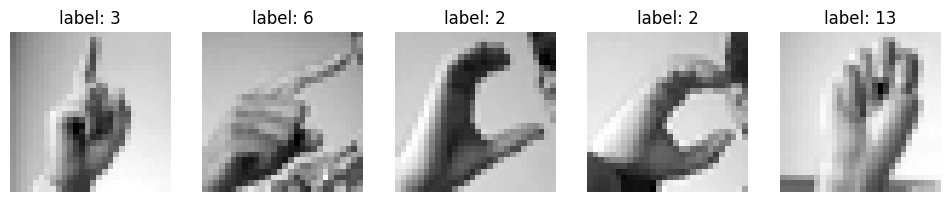

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x = Pixels and y = labels
X_train_full = train_df.drop('label', axis=1).values
y_train_full = train_df['label'].values
X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

images = X_train_full.reshape(-1, 28, 28)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"label: {y_train_full[i]}")
    ax.axis('off')
plt.show()

In [ ]:
# preprocessing
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

X_train_full = X_train_full.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

classes = np.sort(np.unique(y_train_full))
label_to_idx = {old: new for new, old in enumerate(classes)}

y_train_full = to_categorical([label_to_idx[v] for v in y_train_full], num_classes=len(classes))
y_test = to_categorical([label_to_idx[v] for v in y_test], num_classes=len(classes))

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=42, stratify=y_train_full
)

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)
print("classes:", len(classes), "| pixel range:", X_train.min(), "-", X_train.max())

X_train: (21964, 28, 28, 1) | X_val: (5491, 28, 28, 1) | X_test: (7172, 28, 28, 1)
classes: 24 | pixel range: 0.0 - 1.0


In [ ]:
# building the CNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(24, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,840 (886.09 KB)

 Trainable params: 226,840 (886.09 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.3956 - loss: 1.9518 - val_accuracy: 0.8423 - val_loss: 0.5689
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step - accuracy: 0.7663 - loss: 0.7023 - val_accuracy: 0.9643 - val_loss: 0.2160
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.8597 - loss: 0.4117 - val_accuracy: 0.9836 - val_loss: 0.0961
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.9064 - loss: 0.2710 - val_accuracy: 0.9980 - val_loss: 0.0445
Epoch 5/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9326 - loss: 0.2009 - val_accuracy: 0.9980 - val_loss: 0.0253
Epoch 6/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.9437 - loss: 0.1607 - val_accuracy: 0.9984 - val_loss: 0.0174
Epoch 7/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9566 - loss: 0.1294 - val_accuracy: 0.9980 - val_loss: 0.0080
Epoch 8/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.9642 - loss: 0.1033 - 

In [ ]:
model.save('/content/drive/MyDrive/Projects/Sign Language Recognizer/sign_language_cnn.keras')
print("saved")

saved


In [ ]:
# evaluate on the real test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print("test accuracy:", test_acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9283 - loss: 0.2490
test accuracy: 0.9283323884010315


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


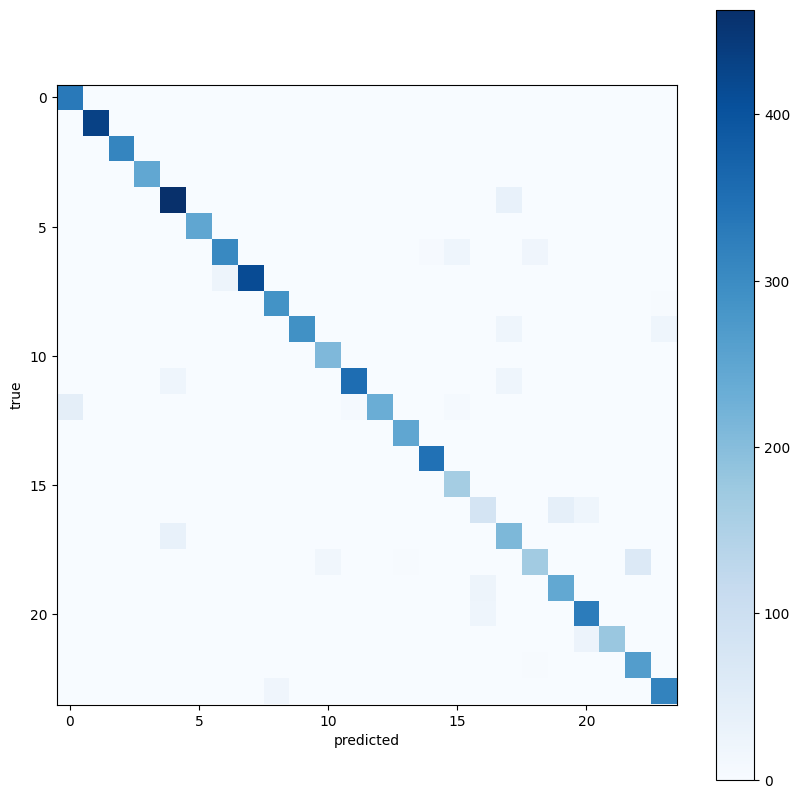

In [ ]:
# confusion matrix

from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10,10))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('predicted')
plt.ylabel('true')
plt.show()

In [ ]:
letters = [chr(65 + c) for c in classes]

for c in range(24):
    correct, total = cm[c][c], cm[c].sum()
    print(f"{letters[c]}: {correct:4d}/{total:4d} = {correct/total:.1%}")

A:  331/ 331 = 100.0%
B:  432/ 432 = 100.0%
C:  310/ 310 = 100.0%
D:  245/ 245 = 100.0%
E:  463/ 498 = 93.0%
F:  247/ 247 = 100.0%
G:  304/ 348 = 87.4%
H:  413/ 436 = 94.7%
I:  286/ 288 = 99.3%
K:  290/ 331 = 87.6%
L:  209/ 209 = 100.0%
M:  353/ 394 = 89.6%
N:  232/ 291 = 79.7%
O:  246/ 246 = 100.0%
P:  347/ 347 = 100.0%
Q:  163/ 164 = 99.4%
R:   82/ 144 = 56.9%
S:  211/ 246 = 85.8%
T:  167/ 248 = 67.3%
U:  244/ 266 = 91.7%
V:  326/ 346 = 94.2%
W:  179/ 206 = 86.9%
X:  265/ 267 = 99.3%
Y:  313/ 332 = 94.3%


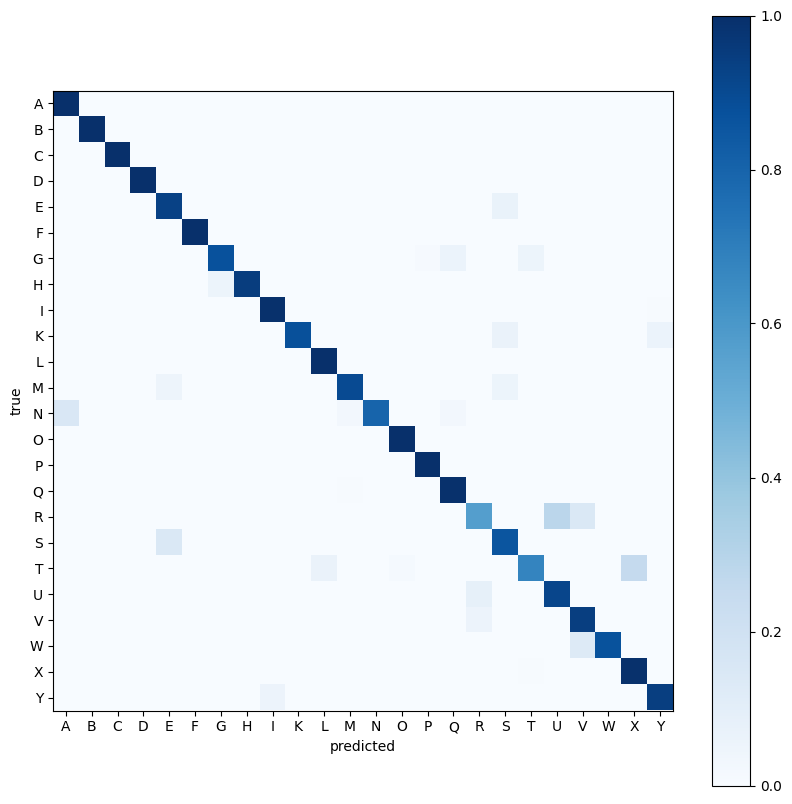

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10,10))
plt.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar()
plt.xticks(range(24), letters)
plt.yticks(range(24), letters)
plt.xlabel('predicted'); plt.ylabel('true')
plt.show()

In [ ]:
# checking the top 12 confusing signs for the model

pairs = []
for t in range(24):
    for p in range(24):
        if t != p and cm[t][p] > 0:
            pairs.append((cm[t][p], letters[t], letters[p]))

pairs.sort(reverse=True)
print("top 12 confusions (count, true -> predicted):")
for count, true_l, pred_l in pairs[:12]:
    print(f"{count:4d}   {true_l} -> {pred_l}")

top 12 confusions (count, true -> predicted):
  62   T -> X
  44   N -> A
  41   R -> U
  35   S -> E
  35   E -> S
  27   W -> V
  23   H -> G
  22   U -> R
  21   R -> V
  21   M -> S
  21   K -> S
  21   G -> Q


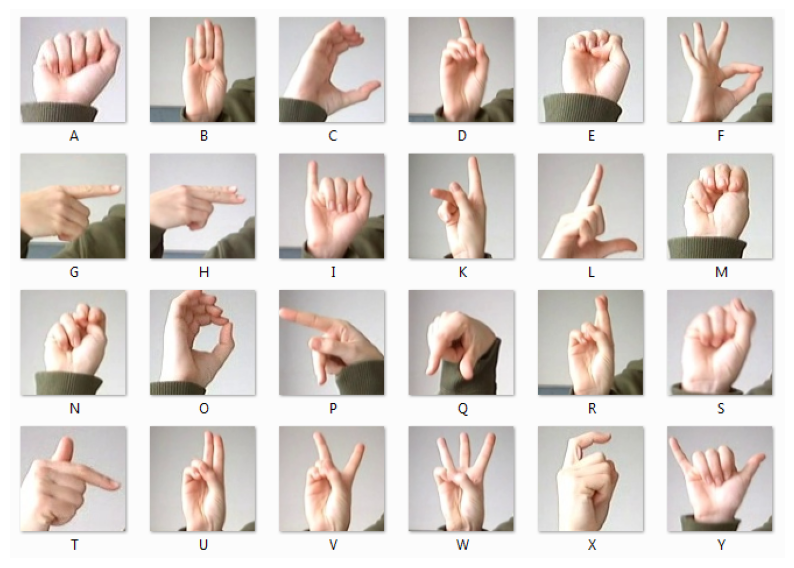

In [ ]:
from PIL import Image
img = Image.open('/content/drive/MyDrive/Projects/Sign Language Recognizer/amer_sign2.png')
plt.figure(figsize=(10,10)); plt.imshow(img); plt.axis('off'); plt.show()

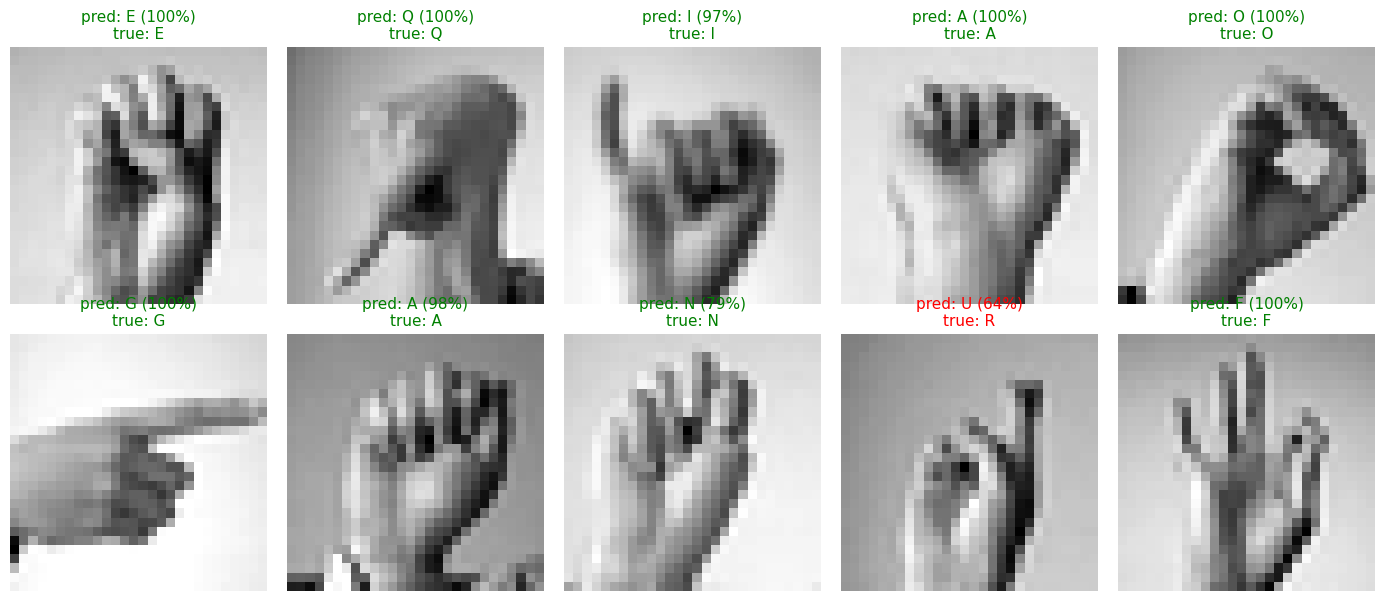

In [ ]:
n = 10
idx = np.random.choice(len(X_test), n, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, i in zip(axes.flat, idx):
    true_l = letters[y_true_classes[i]]
    pred_l = letters[y_pred_classes[i]]
    conf = y_pred[i].max()
    ok = (true_l == pred_l)
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"pred: {pred_l} ({conf:.0%})\ntrue: {true_l}",
                 color='green' if ok else 'red', fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

Saving E_15.png to E_15 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


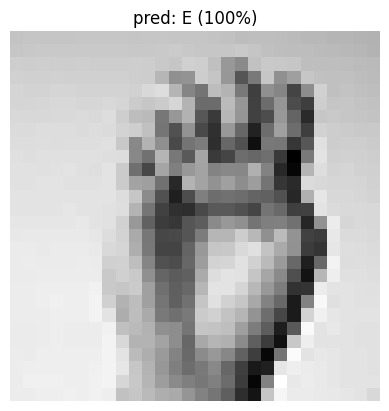

In [ ]:
# upload and predict

from google.colab import files
from PIL import Image

uploaded = files.upload()
fname = list(uploaded.keys())[0]

img = Image.open(fname).convert('L').resize((28, 28))
arr = np.array(img).astype('float32') / 255.0
arr = arr.reshape(1, 28, 28, 1)

pred = model.predict(arr)
pred_class = np.argmax(pred)
conf = pred.max()

plt.imshow(arr.reshape(28, 28), cmap='gray')
plt.title(f"pred: {letters[pred_class]} ({conf:.0%})")
plt.axis('off')
plt.show()